In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv("data.csv")

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.drop("id", axis=1, inplace=True)

In [6]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

In [8]:
df = df.dropna(axis=1, how='all')

In [9]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.956140350877193
Precision: 0.9743589743589743
Recall: 0.9047619047619048
F1 Score: 0.9382716049382716


In [15]:
results = []

for column in X.columns:

    X_temp = X.drop(column, axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    results.append({
        "Removed Feature": column,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

ablation_df = pd.DataFrame(results)

print(ablation_df.sort_values(by="Accuracy"))

            Removed Feature  Accuracy  Precision    Recall        F1
9    fractal_dimension_mean  0.938596   0.972973  0.857143  0.911392
26          concavity_worst  0.938596   0.972973  0.857143  0.911392
6            concavity_mean  0.947368   0.973684  0.880952  0.925000
1              texture_mean  0.947368   1.000000  0.857143  0.923077
8             symmetry_mean  0.947368   0.973684  0.880952  0.925000
14            smoothness_se  0.947368   0.973684  0.880952  0.925000
17        concave points_se  0.947368   0.973684  0.880952  0.925000
4           smoothness_mean  0.947368   0.973684  0.880952  0.925000
18              symmetry_se  0.947368   0.973684  0.880952  0.925000
19     fractal_dimension_se  0.947368   0.973684  0.880952  0.925000
2            perimeter_mean  0.956140   0.974359  0.904762  0.938272
10                radius_se  0.956140   0.974359  0.904762  0.938272
7       concave points_mean  0.956140   0.974359  0.904762  0.938272
5          compactness_mean  0.956

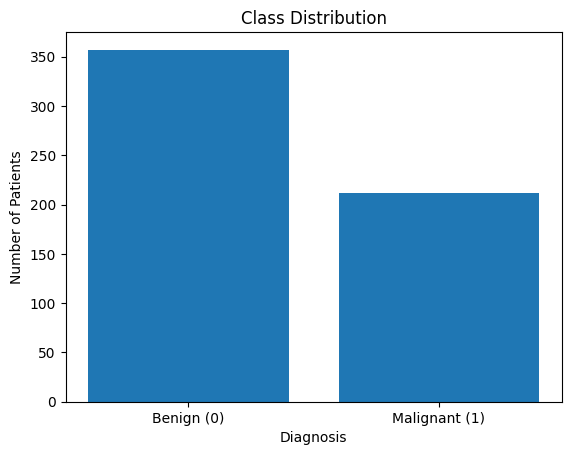

In [16]:
counts = df['diagnosis'].value_counts()

plt.bar(
    ['Benign (0)', 'Malignant (1)'],
    counts
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.show()

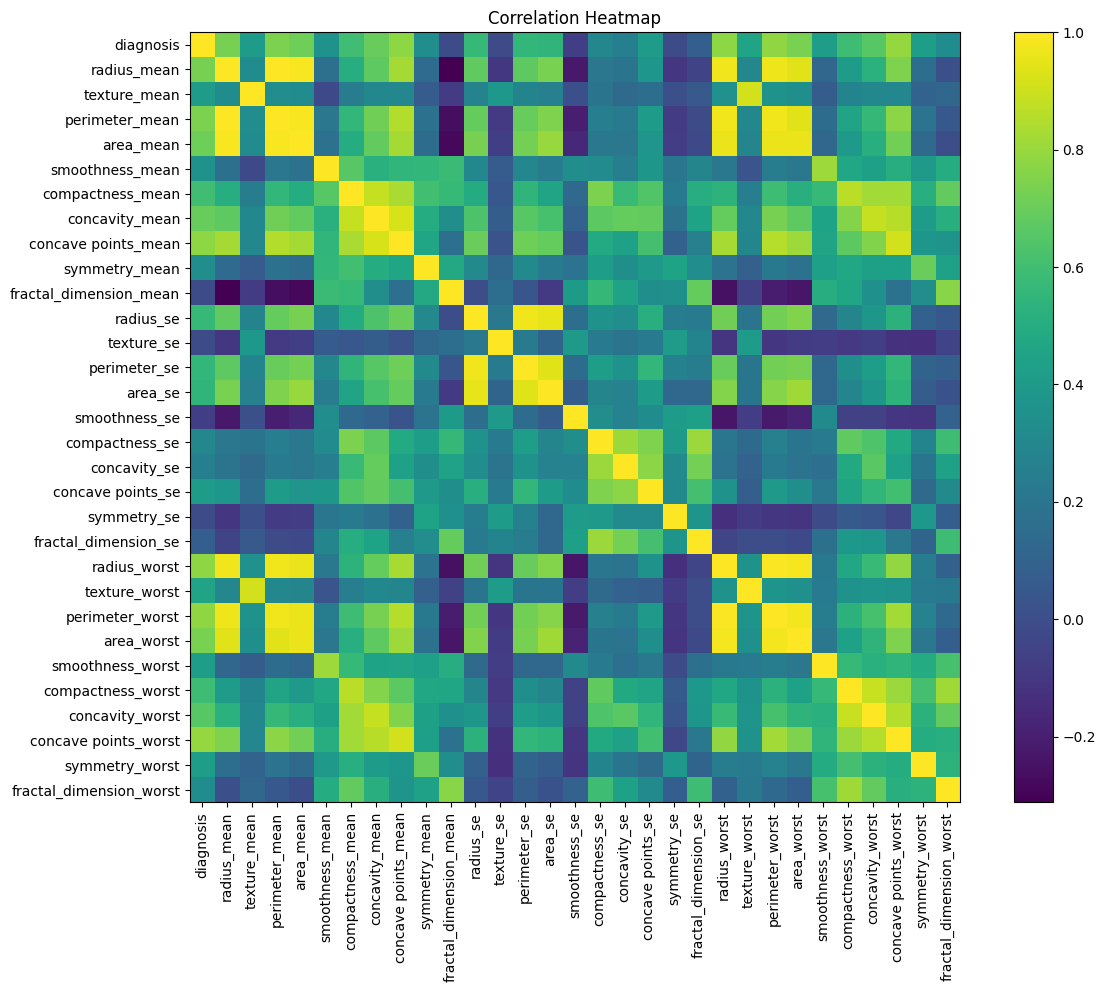

In [17]:
plt.figure(figsize=(14,10))

corr = df.corr()

plt.imshow(corr)
plt.colorbar()

features = corr.columns

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
corr_matrix = df.corr()

strong_corr = corr_matrix.unstack()

strong_corr = strong_corr[
    (strong_corr > 0.8) & (strong_corr < 1.0)
]

print(strong_corr.sort_values(ascending=False).drop_duplicates())

radius_mean              perimeter_mean          0.997855
perimeter_worst          radius_worst            0.993708
radius_mean              area_mean               0.987357
perimeter_mean           area_mean               0.986507
area_worst               radius_worst            0.984015
                         perimeter_worst         0.977578
radius_se                perimeter_se            0.972794
perimeter_mean           perimeter_worst         0.970387
radius_worst             radius_mean             0.969539
perimeter_mean           radius_worst            0.969476
perimeter_worst          radius_mean             0.965137
area_mean                radius_worst            0.962746
                         area_worst              0.959213
perimeter_worst          area_mean               0.959120
area_se                  radius_se               0.951830
perimeter_mean           area_worst              0.941550
area_worst               radius_mean             0.941082
area_se       

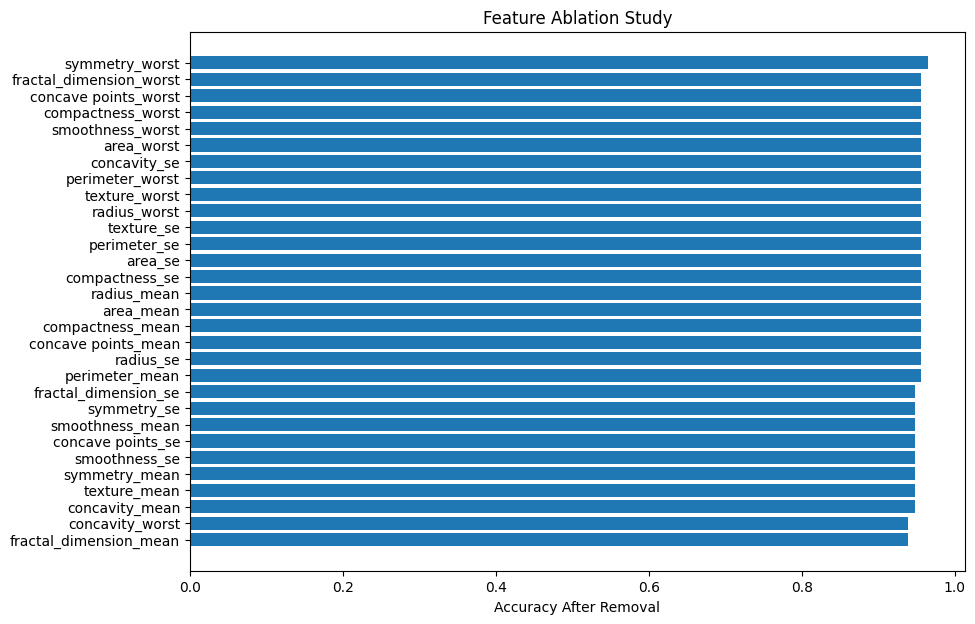

In [19]:
sorted_df = ablation_df.sort_values(by="Accuracy")

plt.figure(figsize=(10,7))

plt.barh(
    sorted_df["Removed Feature"],
    sorted_df["Accuracy"]
)

plt.xlabel("Accuracy After Removal")
plt.title("Feature Ablation Study")

plt.show()

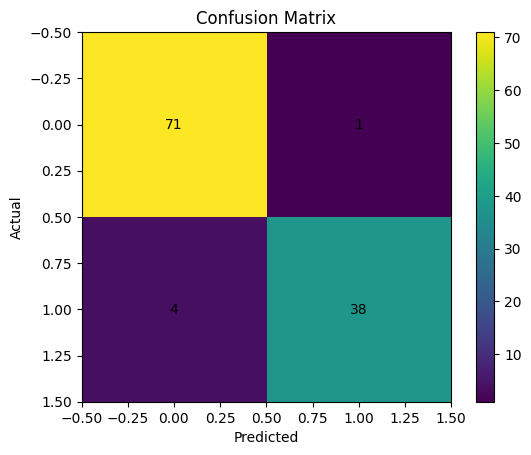

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.show()

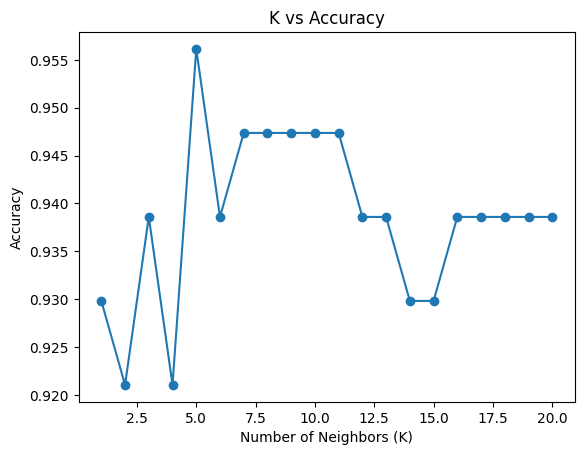

In [21]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')

plt.title("K vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.show()